In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import numpy as np
import healpy as hp
from glob import glob
import matplotlib
import matplotlib.pyplot as plt


from map_functions import SetupAbsThresholdColormap, maskMap, smoothMap, adjust_colorbar_limits

In [30]:
import pypdf as pdf
from pypdf import PdfReader, PdfWriter

In [31]:
# Load in maps
relint = {}
data = {}
bg = {}
sig = {}

root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/sidereal_unblinded'
tiers = [i for i in range(1, 5)]

for tier in tiers:
    
    # Relative intensity maps
    files = glob(f'{root}/tier{tier}/reconstruction/relintensityiter/combined*.fits.gz')
    relint_file = sorted(files)[-1]
    data[tier], bg[tier], relint[tier] = hp.read_map(relint_file, range(3))

    # Significance maps
    files = glob(f'{root}/tier{tier}/reconstruction/significanceiter/significance*.fits.gz')
    sig_file = sorted(files)[-1]
    _, sig[tier], _ = hp.read_map(sig_file, range(3))

In [59]:
def plot_map(skymap,
             cb_ticks=None, cb_label=None,
             half_map=True, threshold=False, 
             llabel='', rlabel='',
             filename=None):

    # Adjust limits of colorbar
    skymap = adjust_colorbar_limits(skymap, cb_ticks)

    # Setup colormap with option for threshold
    colormap = plt.get_cmap('jet')
    if threshold:
        colormap = SetupAbsThresholdColormap(skymap, threshold, cb_ticks)
    colormap.set_under('white')
    colormap.set_bad('gray')
    
    hp.projview(skymap, 
            fig = 1,
            rot = (-180,0,0),
            projection_type = 'mollweide',
            graticule = True,
            cmap = colormap,
            cbar_ticks = cb_ticks,
            fontsize={'cbar_tick_label': 'large'})

    fig = plt.figure(1)
    moll_axis_type = matplotlib.projections.geo.MollweideAxes
    ax = [a for a in fig.get_axes() if type(a) is moll_axis_type][0]

    ax.text(0.05, 0.175, r"360$^\circ$", 
        transform=ax.transAxes, ha='center', fontsize='x-large')
    ax.text(0.95, 0.175, r"0$^\circ$", 
        transform=ax.transAxes, ha='center', fontsize='x-large')

    # Optional text overlay
    lParams = {'size':'xx-large','family':'sans-serif'} #,'weight':'bold'}
    # Label variations:
    #combined_label = rf'$\frac{{\mathrm{{{llabel}}}}}{{\mathrm{{{slabel}}}}}$'  # display as fraction
    #combined_label = rf'{slabel} $\nabla$  |  {llabel} $\Delta$'                # display on one line
    combined_label = rf'{llabel} $\Delta$' + '\n' + rf'{slabel} $\nabla$'
    ax.text(0.05, 0.45, combined_label, 
        #transform=ax.transAxes, ha='left', va='top', fontsize=24, color='white')
        transform=ax.transAxes, ha='left', va='top', fontsize='xx-large', color='white')
    #ax.text(0.05, 0.025, slabel, 
    #    transform=ax.transAxes, ha='left', fontsize='xx-large', color='black')
    ax.text(0.95, 0.45, rlabel, 
        transform=ax.transAxes, ha='right', va='top', fontsize='xx-large', color='white')

    # Labeling for colorbar
    if cb_label != None:
        ax.text(0.5, -0.25, cb_label,
                transform=ax.transAxes, ha='center', fontsize='large')

    # Hide default titling
    ax.set_title('', visible=False)
        
    if filename:
        fig.savefig(filename, bbox_inches='tight')

    plt.show()

In [60]:
def half_sky(in_pdf, out_pdf, rm=0.425):

    reader = PdfReader(in_pdf)
    writer = PdfWriter()
    
    # Get the first page
    page = reader.pages[0]
    
    # Get current dimensions
    box = page.mediabox
    
    # Calculate new top boundary (remove top X% based on argument)
    new_top = box.top - (box.height * rm)
    
    # Apply new boundary to the page
    page.mediabox.upper_left = (box.left, new_top)
    page.mediabox.upper_right = (box.right, new_top)
    
    # Add the modified page to the writer
    writer.add_page(page)
    
    # Save the new PDF file
    with open(out_pdf, "wb") as output_file:
        writer.write(output_file)

Setting to colorbar minimum (view them by removing cb_min/cb_max/cb_ticks)


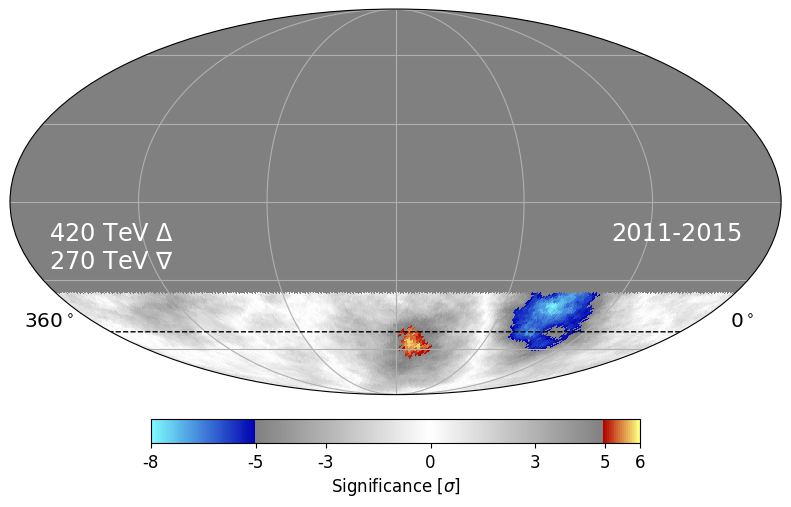

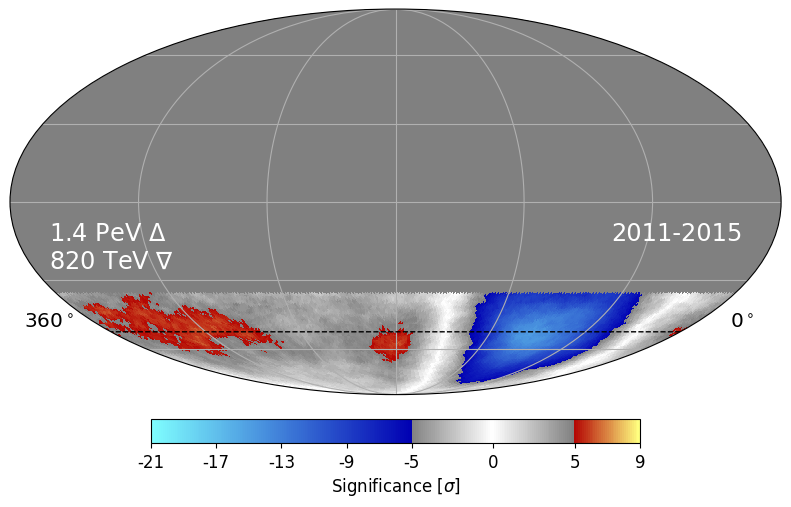

Setting to colorbar maximum (view them by removing cb_min/cb_max/cb_ticks)


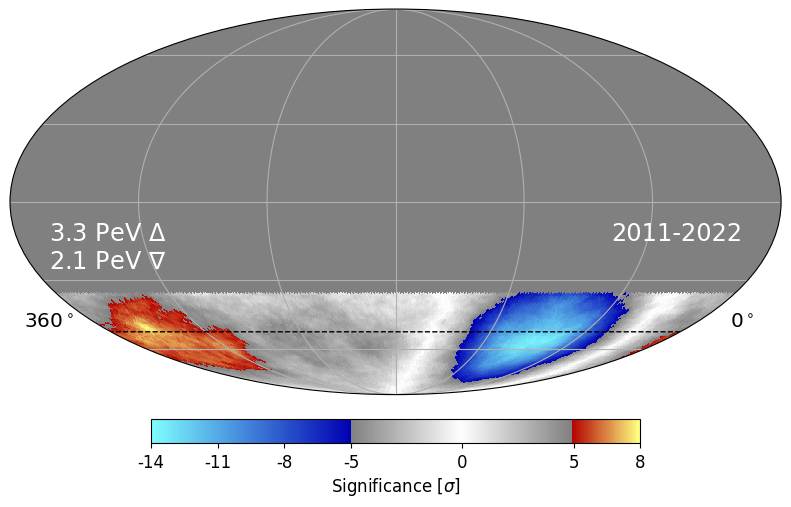

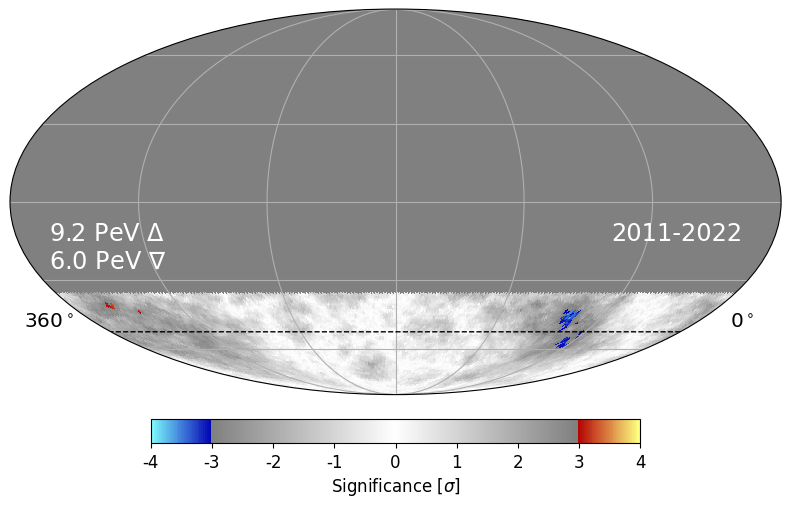

In [63]:
cb_ticks = {1: [-8, -5, -3, 0, 3, 5, 6],
            2: [-21, -17, -13, -9, -5, 0, 5, 9],
            3: [-14, -11, -8, -5, 0, 5, 8],
            4: [-4, -3, -2, -1, 0, 1, 2, 3, 4]
           }

llabels = {1: '420 TeV', 
           2: '1.4 PeV',
           3: '3.3 PeV',
           4: '9.2 PeV'
          }

rlabels = {1: '2011-2015', 
           2: '2011-2015',
           3: '2011-2022',
           4: '2011-2022'
          }

slabels = {1: '270 TeV', 
           2: '820 TeV',
           3: '2.1 PeV',
           4: '6.0 PeV'
          }

for tier in tiers:

    skymap = sig[tier]

    # Mask
    m = maskMap(skymap, decmax=-35.)

    threshold = 3 if tier==4 else 5
    plot_args = {'threshold':threshold,
                 'cb_ticks':cb_ticks[tier],
                 'llabel':llabels[tier],
                 'rlabel':rlabels[tier],
                 'cb_label':r'Significance [$\sigma$]'
                }

    pdf_0 = f'sig_t{tier}_fullsky.pdf'
    pdf_1 = pdf_0.replace('_fullsky','')
    
    plot_map(m, filename=pdf_0, **plot_args)
    half_sky(pdf_0, pdf_1, rm=0.4)

Setting to colorbar minimum (view them by removing cb_min/cb_max/cb_ticks)


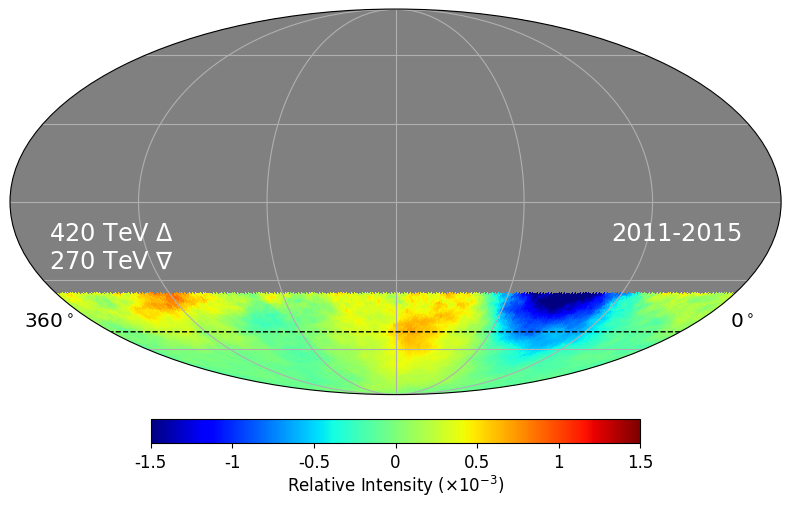

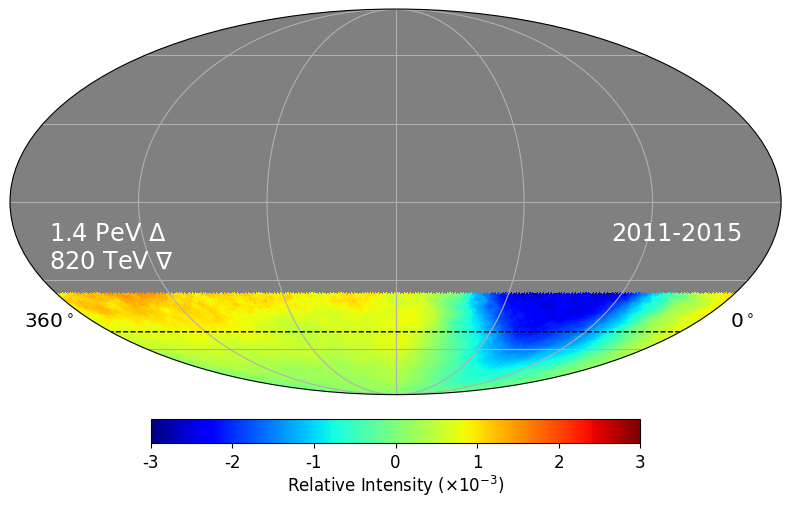

Setting to colorbar minimum (view them by removing cb_min/cb_max/cb_ticks)


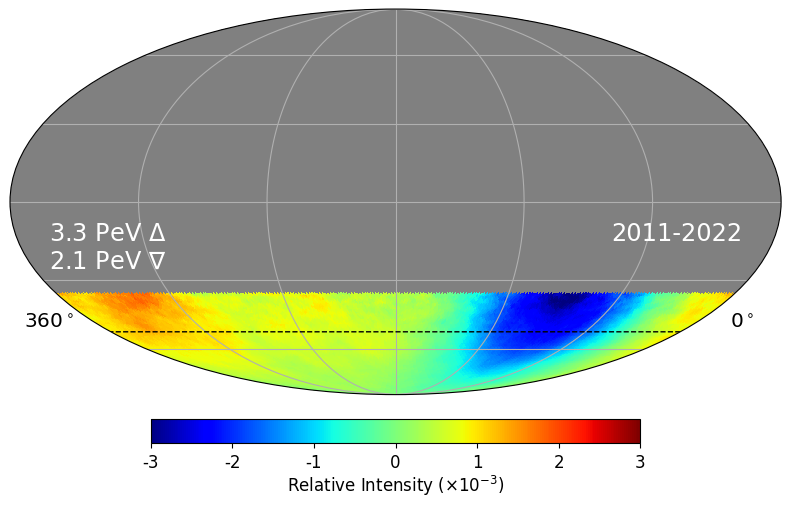

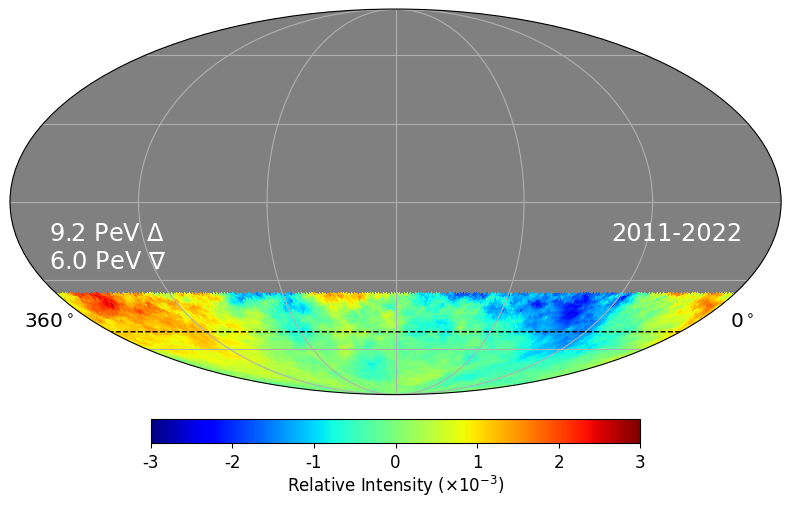

In [64]:
cb_ticks = {1:[-1.5, -1, -0.5, 0, 0.5, 1, 1.5],
            2:[-3, -2, -1, 0, 1, 2, 3],
            3:[-3, -2, -1, 0, 1, 2, 3],
            4:[-3, -2, -1, 0, 1, 2, 3]
           }

llabels = {1: '420 TeV', 
           2: '1.4 PeV',
           3: '3.3 PeV',
           4: '9.2 PeV'
          }

rlabels = {1: '2011-2015', 
           2: '2011-2015',
           3: '2011-2022',
           4: '2011-2022'
          }

slabels = {1: '270 TeV', 
           2: '820 TeV',
           3: '2.1 PeV',
           4: '6.0 PeV'
          }

for tier in tiers:

    smoothed_data = smoothMap(data[tier], 20)
    smoothed_bg   = smoothMap(bg[tier], 20)
    with np.errstate(divide='ignore', invalid='ignore'):
        relint = (smoothed_data - smoothed_bg) / smoothed_bg
    relint *= 1000

    # Mask
    m = maskMap(relint, decmax=-35.)

    plot_args = {'cb_ticks':cb_ticks[tier],
                 'llabel':llabels[tier],
                 'rlabel':rlabels[tier],
                 'cb_label':r'Relative Intensity ($\times 10^{-3}$)'
                }

    pdf_0 = f'relint_t{tier}_fullsky.pdf'
    pdf_1 = pdf_0.replace('_fullsky','')
    
    plot_map(m, filename=pdf_0, **plot_args)
    half_sky(pdf_0, pdf_1, rm=0.4)